# Training Convolutional Neural Networks

## Part 2 of 5: Swapping the MLP for an CNN to classify MNIST images


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torch import inference_mode
from torch.utils.tensorboard import SummaryWriter
import torchvision
import torchvision.transforms as transforms
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(123)

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    ])

train_full = torchvision.datasets.MNIST(root="data/", train=True,  download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root="data/", train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    train_full, 
    [50000, 10000],
    generator=torch.Generator().manual_seed(123)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

#The generator with a fixed seed makes the split reproducible without affecting the global 



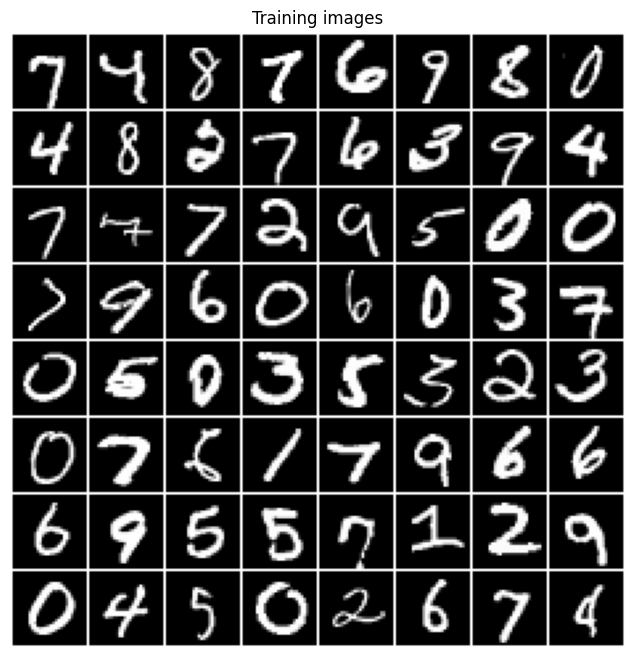

In [3]:
for images, labels in train_loader:  
    break

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images")
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:64], 
    padding=1,
    pad_value=1.0,
    normalize=True),
    (1, 2, 0)))

plt.show()

In [4]:
class PyTorchCNN(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.cnn_layers = torch.nn.Sequential(

            torch.nn.Conv2d(1, 3, kernel_size=5),
            torch.nn.BatchNorm2d(3),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            
            torch.nn.Conv2d(3, 16, kernel_size=3),
            torch.nn.BatchNorm2d(16),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),        
            
            torch.nn.Conv2d(16, 32, kernel_size=3),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2), 
        )
        
        self.fc_layers = torch.nn.Sequential(
            # hidden layer
            torch.nn.Linear(32, 20),
            torch.nn.BatchNorm1d(20),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(20, num_classes)
        )

    def forward(self, x):
        x = self.cnn_layers(x)
        # print(x.shape)
        x = torch.flatten(x, start_dim=1)
        logits = self.fc_layers(x)
        return logits

In [5]:
def train_one_epoch(model, loader, optimizer, criterion, acc_metric, device):
    model.train()
    acc_metric.reset()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    avg_loss = total_loss / len(loader.dataset)
    avg_acc  = acc_metric.compute().item()
    return avg_loss, avg_acc

In [6]:
def train_one_epoch(model, loader, optimizer, criterion, acc_metric, device):
    model.train()
    acc_metric.reset()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    avg_loss = total_loss / len(loader.dataset)
    avg_acc  = acc_metric.compute().item()
    return avg_loss, avg_acc

In [7]:
@inference_mode()
def evaluate(model, loader, criterion, acc_metric, device):
    model.eval()
    acc_metric.reset()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    avg_loss = total_loss / len(loader.dataset)
    avg_acc  = acc_metric.compute().item()
    return avg_loss, avg_acc

In [9]:
# --- Setup ---
torch.manual_seed(123)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = PyTorchCNN(num_classes=10).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

writer = SummaryWriter(log_dir="logs/cnn-mnist")

# Log model graph
dummy = torch.zeros(1, 1, 28, 28).to(device)
writer.add_graph(model, dummy)


In [10]:
# --- Training ---
MAX_EPOCHS = 10

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, train_acc, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, val_acc, device)

    # TensorBoard logging
    writer.add_scalars("Loss", {"train": tr_loss, "val": vl_loss}, epoch)
    writer.add_scalars("Accuracy", {"train": tr_acc, "val": vl_acc}, epoch)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val   Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

writer.close()


Epoch 01/10 | Train Loss: 0.2714  Acc: 0.9336 | Val   Loss: 0.1695  Acc: 0.9489
Epoch 02/10 | Train Loss: 0.0932  Acc: 0.9721 | Val   Loss: 0.1345  Acc: 0.9581
Epoch 03/10 | Train Loss: 0.0747  Acc: 0.9773 | Val   Loss: 0.1419  Acc: 0.9567
Epoch 04/10 | Train Loss: 0.0625  Acc: 0.9806 | Val   Loss: 0.0653  Acc: 0.9800
Epoch 05/10 | Train Loss: 0.0542  Acc: 0.9835 | Val   Loss: 0.0745  Acc: 0.9770
Epoch 06/10 | Train Loss: 0.0481  Acc: 0.9851 | Val   Loss: 0.0724  Acc: 0.9771
Epoch 07/10 | Train Loss: 0.0456  Acc: 0.9849 | Val   Loss: 0.1795  Acc: 0.9490
Epoch 08/10 | Train Loss: 0.0404  Acc: 0.9868 | Val   Loss: 0.0628  Acc: 0.9816
Epoch 09/10 | Train Loss: 0.0376  Acc: 0.9878 | Val   Loss: 0.0604  Acc: 0.9831
Epoch 10/10 | Train Loss: 0.0348  Acc: 0.9894 | Val   Loss: 0.0563  Acc: 0.9823


In [11]:
# --- Test ---
test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
te_loss, te_acc = evaluate(model, test_loader, criterion, test_acc, device)
print(f"\nTest Loss: {te_loss:.4f} | Test Accuracy: {te_acc:.4f}")


Test Loss: 0.0509 | Test Accuracy: 0.9844
